In [285]:
# 라이브러리 임포트
import numpy as np
import cv2
from keras.models import load_model
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# 이미지 전처리
def preprocess_image(image):
    # 이미지 정규화
    image = image / 255.0
    # 넘파이 어레이 형식으로 반환
    return np.array([image])

# 이미지 후처리
def process_image(predict, label):
    # 이미지 예측된 라벨 표시
    predict_img = label[np.argmax(predict)]
    # 예측된 라벨 반환
    return predict_img

# 모델 불러오기
l_m = load_model('best_m.keras')

def main(idx):
    # fashion_mnist 데이터 중 test 데이터만 불러오기
    (_,(images, labels)) = fashion_mnist.load_data()
    # 라벨을 numpy로 지정해서 인덱스화 하기
    label = np.array(['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

    # 이미지 전처리 함수에 idx에 해당하는 이미지 넣기
    image = preprocess_image(images[idx])
    # 전처리 된 이미지 예측하기
    predict = l_m.predict(image, verbose=0)
    # 이미지 후처리 함수에 예측결과와 라벨 전달
    result = process_image(predict, label)

    # 시각화
    plt.title(f'predict : {result}\n labels : {label[labels[idx]]}')
    plt.imshow(images[idx], cmap='binary')
    plt.axis('off')
    plt.show()

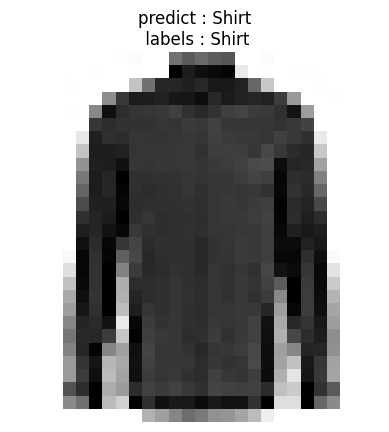

In [331]:
# fashion_mnist의 test 이미지 10000장 중 랜덤으로 지정
idx = np.random.randint(0, 10000)
main(idx)